In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.optimize import curve_fit

path_root = "F:/collaborations/Tim_Hermans/aslc_intertidal"
os.chdir(path_root)

import src.functions as f

def run_simulation(amplitude_annual_cycle = np.linspace(0., 1.5, 100), amplitude_S2 = 0, sigma_w = 0.0, n_years = 10):

    def identify_intertidal_zones(amplitude_annual_cycle, amplitude_S2, sigma, n_years, dz = 0.01):

        _, water_level, _ = f.create_waterlevel_timeseries(amplitude_annual_cycle = amplitude_annual_cycle, amplitude_S2 = amplitude_S2, amplitude_M2 = 1, sigma = sigma, n_years = n_years)
        water_level = water_level/2 # Convert from amplitude to tidal range
        _, low_waterlevel, high_waterlevel = f.calculate_highlow_water(water_level)
        elevation, emergence_freq, inundation_freq = f.calculate_inundation_metrics(low_waterlevel, high_waterlevel, dz)

        supratidal_boundary = elevation[(inundation_freq >= 0.01).argmin()]
        upper_intertidal_boundary = elevation[(inundation_freq <= 0.99).argmax()]
        lower_intertidal_boundary = elevation[(emergence_freq <= 0.99).argmin()]
        subtidal_boundary = elevation[(emergence_freq >= 0.01).argmax()]

        return supratidal_boundary, upper_intertidal_boundary, lower_intertidal_boundary, subtidal_boundary

    rho = 0.021
    sigma = sigma_w*np.sqrt(2*rho)

    n = amplitude_annual_cycle.size
    supratidal_boundary       = np.array([np.nan]*n)
    upper_intertidal_boundary = np.array([np.nan]*n)
    lower_intertidal_boundary = np.array([np.nan]*n)
    subtidal_boundary         = np.array([np.nan]*n)
    for i in range(n):
        supratidal_boundary[i], upper_intertidal_boundary[i], lower_intertidal_boundary[i], subtidal_boundary[i] = identify_intertidal_zones(amplitude_annual_cycle[i], amplitude_S2, sigma, n_years)
        print(f'{i+1}/{n}')

    return amplitude_annual_cycle, supratidal_boundary, upper_intertidal_boundary, lower_intertidal_boundary, subtidal_boundary

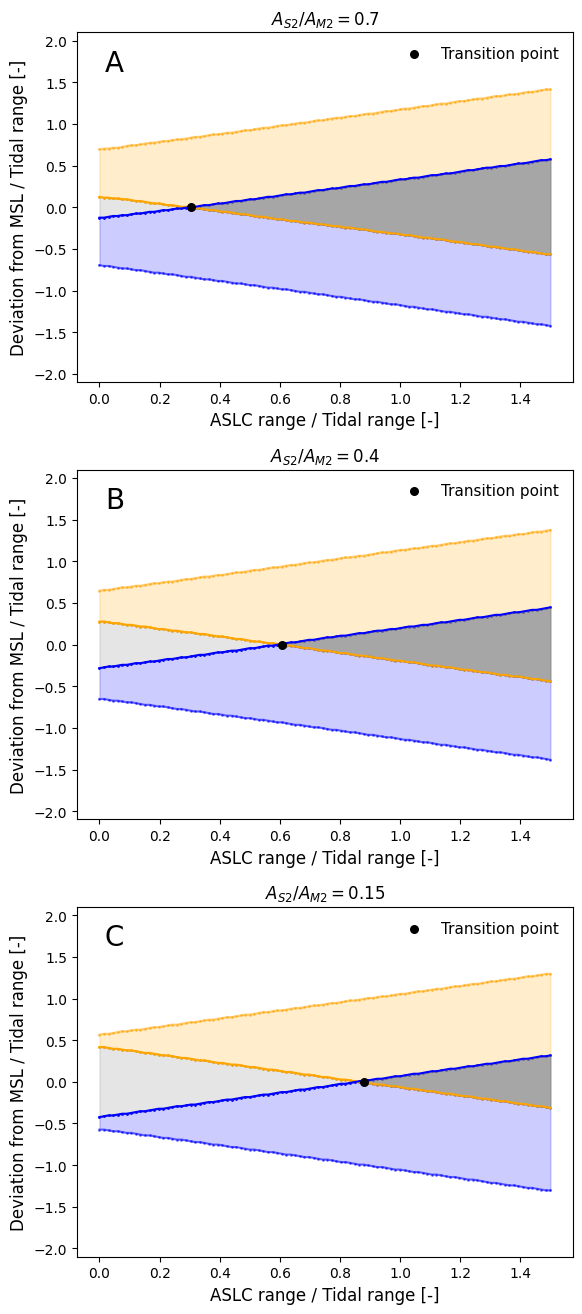

In [3]:
def figure_s1_multipanel(path_png = None, path_bin = './bin/supp_note_1/figure_s1', amplitude_S2 = [0.70, 0.40, 0.15]):

    def figure_s1_panel(ax, path_bin, amplitude_S2 = 0.4, amplitude_M2 = 1, n_years = 10, legend = False):

        def plot_panel(ax, amplitude_annual_cycle, supratidal_boundary, upper_intertidal_boundary, lower_intertidal_boundary, subtidal_boundary):

            # Figure 2b
            ax.plot(amplitude_annual_cycle, supratidal_boundary, c = 'orange', alpha = 0.5)
            ax.plot(amplitude_annual_cycle, upper_intertidal_boundary, c = 'orange')
            ax.plot(amplitude_annual_cycle, lower_intertidal_boundary, c = 'blue')
            ax.plot(amplitude_annual_cycle, subtidal_boundary, c = 'blue', alpha = 0.5)
            ax.scatter(amplitude_annual_cycle, supratidal_boundary, c = 'orange', s = 1, alpha = 0.5)
            ax.scatter(amplitude_annual_cycle, upper_intertidal_boundary, c = 'orange', s = 1, alpha = 1.0)
            ax.scatter(amplitude_annual_cycle, lower_intertidal_boundary, c = 'blue', s = 1, alpha = 1.0)
            ax.scatter(amplitude_annual_cycle, subtidal_boundary, c = 'blue', s = 1, alpha = 0.5)

            def closest_to(x, seq):
                return np.argmin(np.abs(seq - x))

            transition_point = amplitude_annual_cycle[closest_to(upper_intertidal_boundary, 0)]

            ax.fill_between(x = amplitude_annual_cycle[amplitude_annual_cycle <= transition_point], 
                            y1 = (upper_intertidal_boundary)[amplitude_annual_cycle <= transition_point], 
                            y2 = (lower_intertidal_boundary)[amplitude_annual_cycle <= transition_point], color = 'grey', alpha = 0.2)
            ax.fill_between(x = amplitude_annual_cycle[amplitude_annual_cycle > transition_point], 
                            y1 = (upper_intertidal_boundary)[amplitude_annual_cycle > transition_point], 
                            y2 = (lower_intertidal_boundary)[amplitude_annual_cycle > transition_point], color = 'grey', alpha = 0.7)

            ax.fill_between(x = amplitude_annual_cycle, 
                            y1 = (supratidal_boundary), 
                            y2 = np.maximum(lower_intertidal_boundary, upper_intertidal_boundary), color = 'orange', alpha = 0.2)

            ax.fill_between(x = amplitude_annual_cycle, 
                            y1 = (subtidal_boundary), 
                            y2 = np.minimum(lower_intertidal_boundary, upper_intertidal_boundary), color = 'blue', alpha = 0.2)

            ax.scatter(transition_point, 0, s = 30, c = 'black', zorder = 2, label = 'Transition point')
            ax.set_ylabel('Deviation from MSL / Tidal range [-]', fontsize = 12)
            ax.set_xlabel('ASLC range / Tidal range [-]', fontsize = 12)
            ax.set_title(rf'$A_{{S2}}/A_{{M2}} = {np.round(amplitude_S2/amplitude_M2,3)}$')
            if legend:
                ax.legend(frameon = False, fontsize = 11)
            ax.set_ylim(-2.1, 2.1)

        # (Optionally) Run simulation
        if os.path.exists(path_bin) == False:
            print('Running simulation...')
            amplitude_annual_cycle, supratidal_boundary, upper_intertidal_boundary, lower_intertidal_boundary, subtidal_boundary = run_simulation(amplitude_S2 = amplitude_S2, n_years = n_years)
            np.save(path_bin, (amplitude_annual_cycle, supratidal_boundary, upper_intertidal_boundary, lower_intertidal_boundary, subtidal_boundary))

        # Load simulation results
        amplitude_annual_cycle, supratidal_boundary, upper_intertidal_boundary, lower_intertidal_boundary, subtidal_boundary = np.load(path_bin)

        # Plot figure
        plot_panel(ax, amplitude_annual_cycle, supratidal_boundary, upper_intertidal_boundary, lower_intertidal_boundary, subtidal_boundary)

    n = len(amplitude_S2)
    fig = plt.figure(figsize=(6.4,(4.8 + 0.5)*n))
    gs1 = fig.add_gridspec(n,1,hspace=.25, wspace=.0) #define subplot grid
    letter_label = ['A','B','C']
    for i in range(n):

        ax = fig.add_subplot(gs1[i,0])
        figure_s1_panel(ax, path_bin = f'{path_bin}/figure_s1-{amplitude_S2[i]:.2f}.npy', amplitude_S2 = amplitude_S2[i], n_years = 1, legend = True)
        ax.text(x = 0.05, y = 1.9, s = letter_label[i], fontsize = 20, horizontalalignment = 'center', verticalalignment = 'top')

    if path_png is not None:
        plt.savefig(path_png, dpi = 300, bbox_inches = "tight", pad_inches = 0.2)
    plt.show()

figure_s1_multipanel(path_png = './figures/supp_note_1/figure_s1/figure_s1.png', path_bin = './bin/supp_note_1/figure_s1', amplitude_S2 = [0.70, 0.40, 0.15])

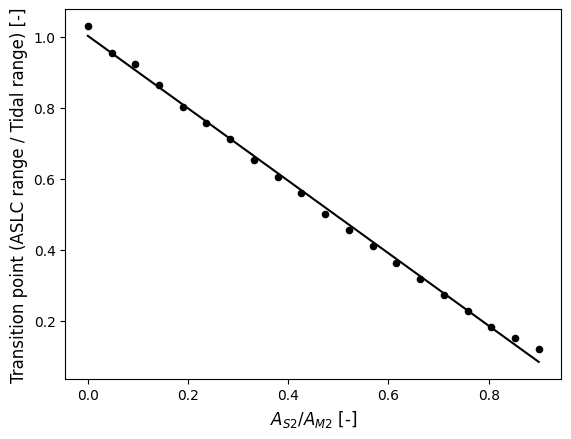

y = 1.002 + -1.02 x


In [4]:
def figure_s2(path_bin, path_png = None):

    def run_batch_sim(path_bin):
        
        # Run simulation
        n        = 100
        n_trials = 20
        n_years  = 20

        amplitude_annual_cycle = np.tile(np.linspace(0., 1.5, n), reps = n_trials).reshape(n_trials,n).T
        amplitude_S2 = np.tile(np.linspace(0., 0.9, n_trials), reps = n).reshape(n,n_trials)
        sigma_w = np.array([0.]*n*n_trials).reshape(n,n_trials)
        rho = 0.021
        sigma = sigma_w*np.sqrt(2*rho)

        supratidal_boundary       = np.array([np.nan]*n*n_trials).reshape(n,n_trials)
        upper_intertidal_boundary = np.array([np.nan]*n*n_trials).reshape(n,n_trials)
        lower_intertidal_boundary = np.array([np.nan]*n*n_trials).reshape(n,n_trials)
        subtidal_boundary         = np.array([np.nan]*n*n_trials).reshape(n,n_trials)
        for iy in range(n_trials):
            supratidal_boundary[:,iy], upper_intertidal_boundary[:,iy], lower_intertidal_boundary[:,iy], subtidal_boundary[:,iy] = run_simulation(amplitude_S2[0,iy], sigma[0,iy], n_years, amplitude_annual_cycle[:,iy])
            print(f'{iy+1}/{n_trials} trials')

        np.save(path_bin, (amplitude_annual_cycle, amplitude_S2, sigma_w, supratidal_boundary, upper_intertidal_boundary, lower_intertidal_boundary, subtidal_boundary))

    # (Optionally) Run simulation
    if os.path.exists(path_bin) == False:
        print('Running simulation...')
        run_batch_sim(path_bin)

    # Load simulation results
    amplitude_annual_cycle, s2m2_ratio, _, _, upper_intertidal_boundary, _, _ = np.load(path_bin)
    amplitude_annual_cycle = amplitude_annual_cycle[:,0]
    s2m2_ratio = s2m2_ratio[0,:]

    def closest_to(x, seq):
        return np.argmin(np.abs(seq - x))
    
    transition_point = np.array([np.nan]*upper_intertidal_boundary.shape[1])
    for i in range(upper_intertidal_boundary.shape[1]):
        transition_point[i] = amplitude_annual_cycle[closest_to(upper_intertidal_boundary[:,i], 0)]

    def linear_model(x, a, b):
        return a + b*x

    par, _ = curve_fit(linear_model, s2m2_ratio, transition_point, p0 = (1,1))
    xp = np.linspace(s2m2_ratio.min(), s2m2_ratio.max(), 100)
    yp = linear_model(xp, *par)

    plt.plot(xp, yp, c = 'black')
    plt.scatter(s2m2_ratio, transition_point, c = 'black', s = 20)
    plt.xlabel('$A_{S2}$/$A_{M2}$ [-]', fontsize = 12)
    plt.ylabel('Transition point (ASLC range / Tidal range) [-]', fontsize = 12)
    if path_png is not None:
        plt.savefig(path_png, dpi = 300)
    plt.show()
    print(f'y = {np.round(par[0],3)} + {np.round(par[1],3)} x')

figure_s2(path_bin = './bin/supp_note_1/figure_s2/figure_s2.npy', path_png = './figures/supp_note_1/figure_s2/figure_s2.png')